In [1]:
!pip install -r requirements.txt --upgrade --force-reinstall

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached keras-3.14.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached wordcloud-1.9.6-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached google_ai_generativelanguage-0.6.18-py3-none-any.whl.metadata (9.8 kB)
  Using cached langchain_google_genai-2.1.2-py3-none-any.whl.metadata (4.7 kB)
  Using cached grpcio_status-1.80.0-py3-none-any.wh

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
error: uninstall-no-record-file

Cannot uninstall pygments None

The package's contents are unknown: no RECORD file was found for pygments.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps pygments==2.19.2


In [2]:
#dl packages
from keras.models import Sequential
from keras.layers import Embedding,LSTM,Dense,Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import one_hot

from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
#ml packages
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import pickle
import nltk
import re
from nltk.stem import PorterStemmer
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

C:\Users\Monika\anaconda3\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [3]:
train_data = pd.read_csv("train.txt",header=None,sep=';',names=['Comment','Emotion'],encoding='utf-8')
train_data['length']=[len(x) for x in train_data['Comment']]

In [4]:
train_data

,Comment,Emotion,length
0,i didnt feel humiliated,sadness,23
1,i can go from feeling so hopeless to so damned...,sadness,108
2,im grabbing a minute to post i feel greedy wrong,anger,48
3,i am ever feeling nostalgic about the fireplac...,love,92
4,i am feeling grouchy,anger,20
...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101
15996,i am now turning and i feel pathetic that i am...,sadness,102
15997,i feel strong and good overall,joy,30
15998,i feel like this was such a rude comment and i...,anger,59


In [5]:
train_data.shape

(16000, 3)

In [6]:
train_data.isnull().sum()

Comment    0
Emotion    0
length     0
dtype: int64

In [7]:
train_data.duplicated().sum()

np.int64(1)

In [8]:
train_data.drop_duplicates(inplace=True)

EDA

In [9]:
train_data['Emotion'].value_counts()

Emotion
joy         5361
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

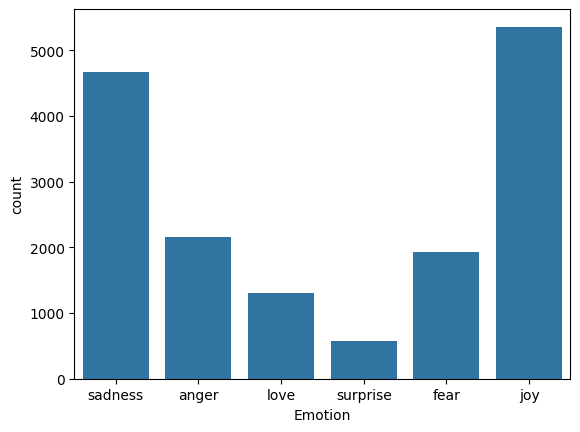

In [10]:
sns.countplot(x=train_data['Emotion'])
plt.show()

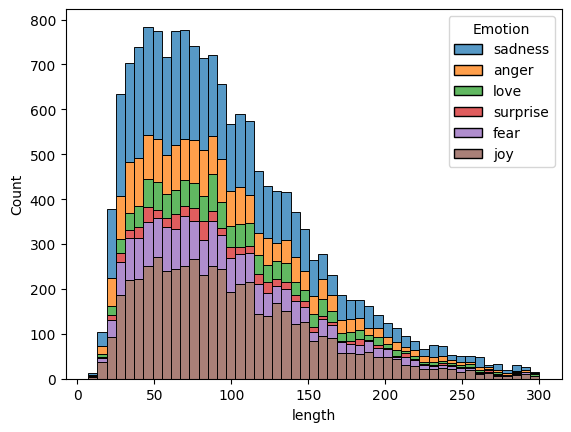

In [11]:
#data distribution
df2 = train_data.copy()
#convert the length column to a numpy array
length_values = df2['length'].values
sns.histplot(data=df2,x='length',hue='Emotion',multiple='stack')
plt.show()

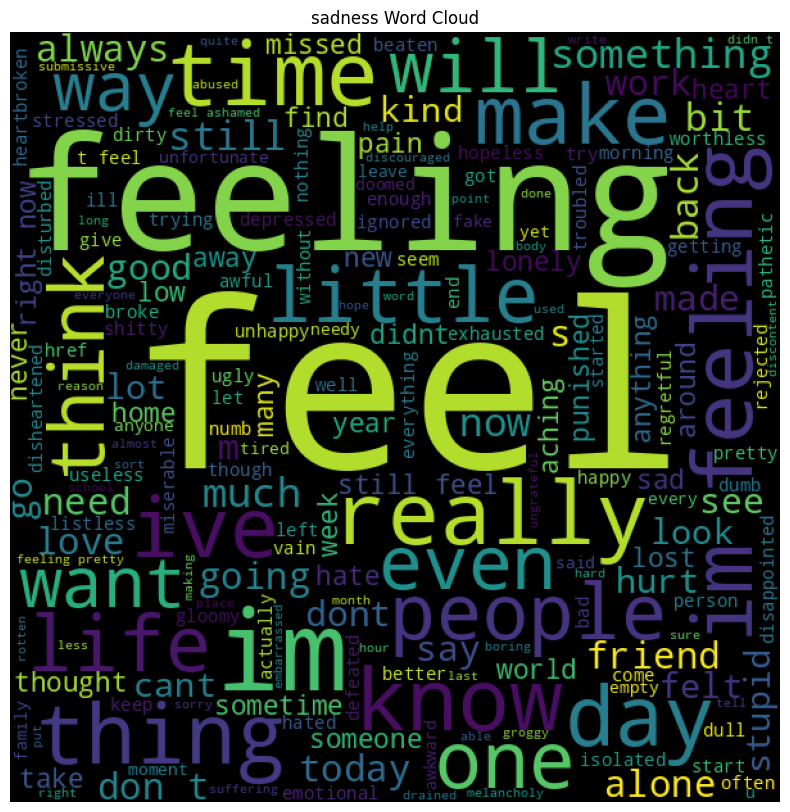

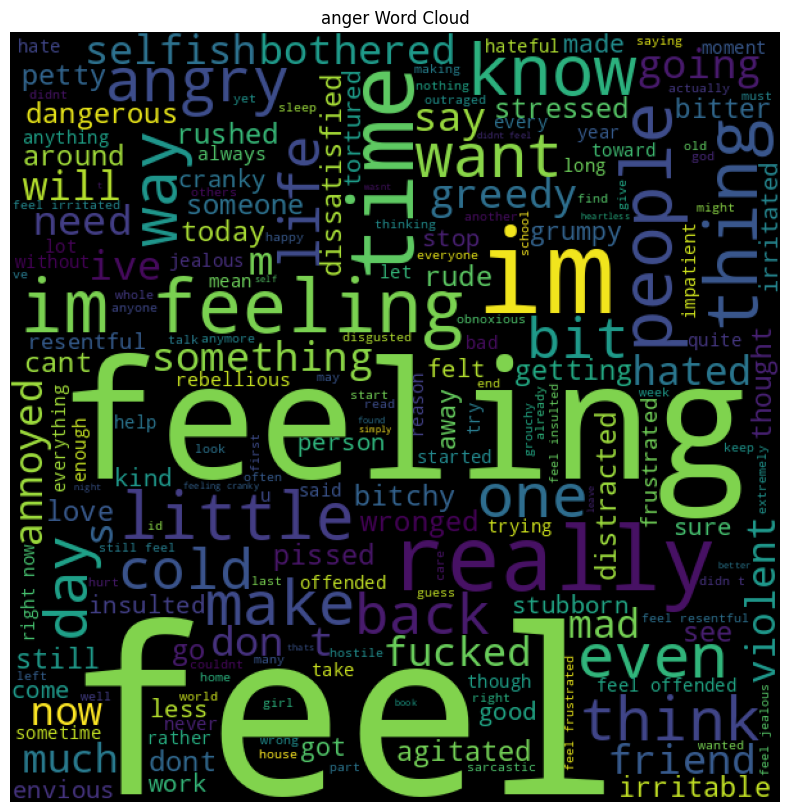

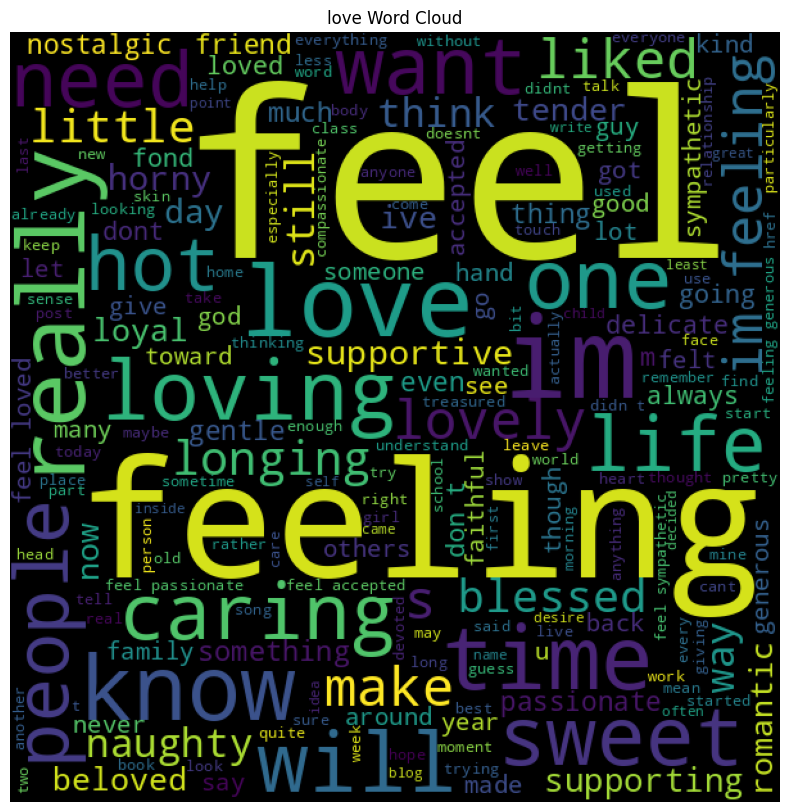

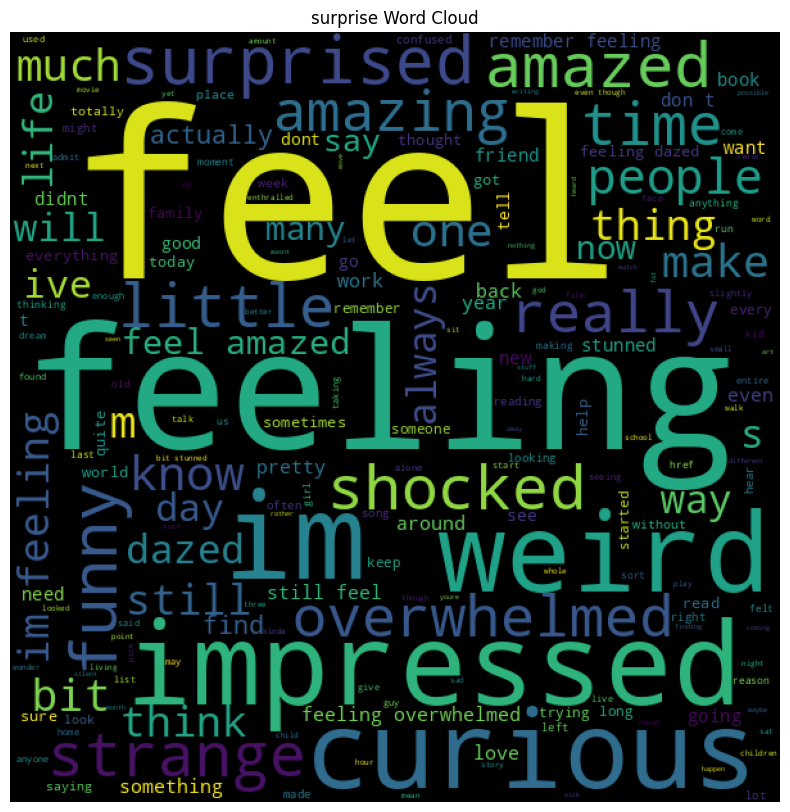

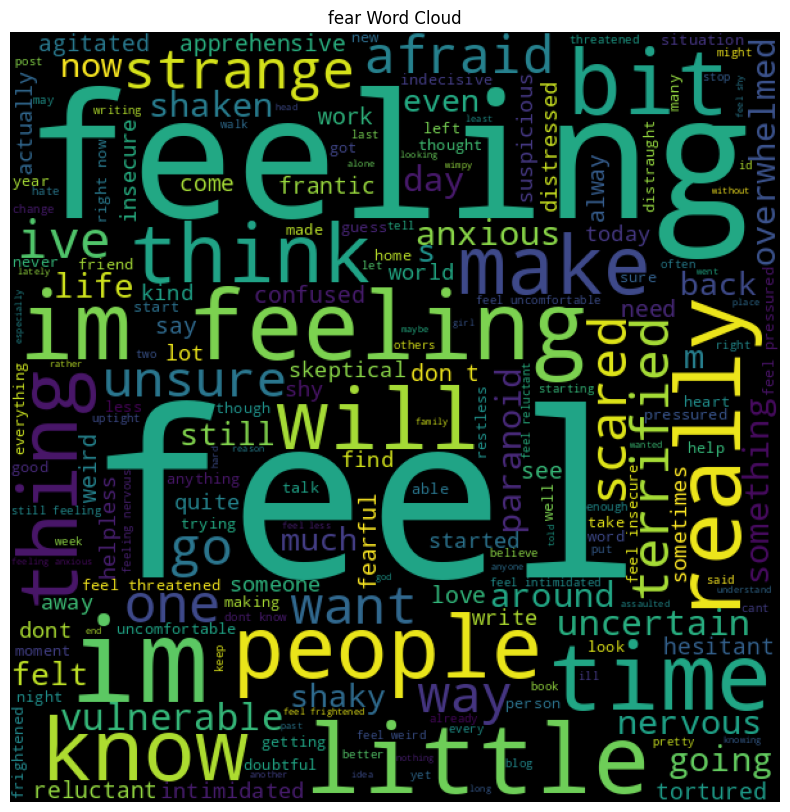

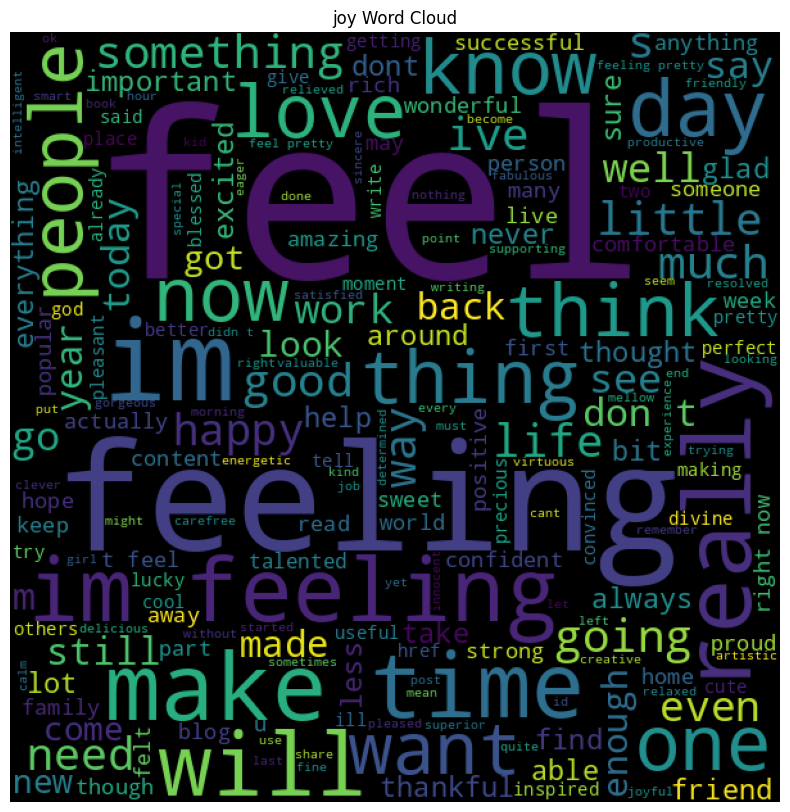

In [12]:
#word cloud for each emotions
def words_cloud(wordcloud,emotion):
    plt.figure(figsize=(10,10))
    plt.title(emotion+ " Word Cloud")
    plt.imshow(wordcloud)
    plt.axis("off")
emotions_list = train_data['Emotion'].unique()
for emotion in emotions_list:
    text = " ".join([sentence for sentence in train_data.loc[train_data['Emotion']==emotion,'Comment']])
    wordcloud = WordCloud(width=600,height=600).generate(text)
    words_cloud(wordcloud,emotion)

Data Preprocessing

Encode emotions

In [13]:
lb = LabelEncoder()
train_data['Emotion_Encoded']=lb.fit_transform(train_data['Emotion'])

In [14]:
train_data

,Comment,Emotion,length,Emotion_Encoded
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,0
3,i am ever feeling nostalgic about the fireplac...,love,92,3
4,i am feeling grouchy,anger,20,0
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101,4
15996,i am now turning and i feel pathetic that i am...,sadness,102,4
15997,i feel strong and good overall,joy,30,2
15998,i feel like this was such a rude comment and i...,anger,59,0


Applying Machine Learning

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [16]:
df = train_data.copy() #copy df from train_data because we will use this for deep learning next

In [17]:
df

,Comment,Emotion,length,Emotion_Encoded
0,i didnt feel humiliated,sadness,23,4
1,i can go from feeling so hopeless to so damned...,sadness,108,4
2,im grabbing a minute to post i feel greedy wrong,anger,48,0
3,i am ever feeling nostalgic about the fireplac...,love,92,3
4,i am feeling grouchy,anger,20,0
...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101,4
15996,i am now turning and i feel pathetic that i am...,sadness,102,4
15997,i feel strong and good overall,joy,30,2
15998,i feel like this was such a rude comment and i...,anger,59,0


In [18]:
#data cleaning and preprocessing
stopwords = set(nltk.corpus.stopwords.words('english'))
def clean_text(text):
    stemmer = PorterStemmer()
    text = re.sub("[^a-zA-Z]"," ",text)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stopwords]
    return " ".join(text)
clean_text("I am 344 % love hating,hated,loved")
df['cleaned_comment'] = df['Comment'].apply(clean_text)

In [19]:
df

,Comment,Emotion,length,Emotion_Encoded,cleaned_comment
0,i didnt feel humiliated,sadness,23,4,didnt feel humili
1,i can go from feeling so hopeless to so damned...,sadness,108,4,go feel hopeless damn hope around someon care ...
2,im grabbing a minute to post i feel greedy wrong,anger,48,0,im grab minut post feel greedi wrong
3,i am ever feeling nostalgic about the fireplac...,love,92,3,ever feel nostalg fireplac know still properti
4,i am feeling grouchy,anger,20,0,feel grouchi
...,...,...,...,...,...
15995,i just had a very brief time in the beanbag an...,sadness,101,4,brief time beanbag said anna feel like beaten
15996,i am now turning and i feel pathetic that i am...,sadness,102,4,turn feel pathet still wait tabl sub teach degre
15997,i feel strong and good overall,joy,30,2,feel strong good overal
15998,i feel like this was such a rude comment and i...,anger,59,0,feel like rude comment im glad


In [20]:
#Train-test split
X_train,X_test,y_train,y_test = train_test_split(df['cleaned_comment'],df['Emotion_Encoded'],test_size=0.2,random_state=42)

In [21]:
# vectorization using TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [22]:
classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC()
}
for name, clf in classifiers.items():
    print(f"\n================{name}====================")
    clf.fit(X_train_tfidf,y_train)
    y_pred_tfidf = clf.predict(X_test_tfidf)
    print(f"\nAccuracy using TF-IDF: {accuracy_score(y_test,y_pred_tfidf)}")
    print("classification Report:")
    print(classification_report(y_test,y_pred_tfidf))


================Multinomial Naive Bayes====================

Accuracy using TF-IDF: 0.6590625
classification Report:
              precision    recall  f1-score   support

           0       0.95      0.32      0.48       439
           1       0.88      0.23      0.37       375
           2       0.58      0.98      0.73      1027
           3       1.00      0.03      0.05       303
           4       0.72      0.91      0.80       950
           5       1.00      0.02      0.04       106

    accuracy                           0.66      3200
   macro avg       0.85      0.42      0.41      3200
weighted avg       0.76      0.66      0.59      3200


================Logistic Regression====================

Accuracy using TF-IDF: 0.825
classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83       439
           1       0.85      0.72      0.78       375
           2       0.76      0.94      0.84      1027
           3

In [23]:
lg = LogisticRegression()
lg.fit(X_train_tfidf,y_train)
y_pred_lg = lg.predict(X_test_tfidf)

In [24]:
def prediction(input_text):
    cleaned_text = clean_text(input_text)
    input_vectorized = tfidf_vectorizer.transform([cleaned_text])
    
    # predict class label
    predicted_label = lg.predict(input_vectorized)[0]
    
    # get emotion name from label
    predicted_emotion = lb.inverse_transform([predicted_label])[0]
    
    # get confidence score (probability of predicted class)
    confidence = np.max(lg.predict_proba(input_vectorized))
    
    return predicted_emotion, predicted_label, confidence

sentences = [
    "I didn't feel humiliated.",
    "I feel strong and good overall.",
    "I am grabbing a minute to post because I feel greedy and wrong.",
    "He was speechless when he found out he was accepted into the new job.",
    "This is outrageous, how can you talk like that?",
    "I feel like I am all alone in this world.",
    "He is really sweet and caring.",
    "You made me feel very crazy.",
    "I am feeling nostalgic about the fireplace, knowing it is still there.",
    "I am feeling grouchy today.",
    "He hates you."
]

for sent in sentences:
    print(sent)
    predicted_emotion, predicted_label, confidence = prediction(sent)
    print("predicted emotion:", predicted_emotion)
    print("predicted label:", predicted_label)
    print("confidence:", confidence)
    print("===============================================")


I didn't feel humiliated.
predicted emotion: sadness
predicted label: 4
confidence: 0.9565377450822933
I feel strong and good overall.
predicted emotion: joy
predicted label: 2
confidence: 0.8966211353124065
I am grabbing a minute to post because I feel greedy and wrong.
predicted emotion: anger
predicted label: 0
confidence: 0.9377289008586187
He was speechless when he found out he was accepted into the new job.
predicted emotion: joy
predicted label: 2
confidence: 0.5388806860963768
This is outrageous, how can you talk like that?
predicted emotion: anger
predicted label: 0
confidence: 0.7122129612902176
I feel like I am all alone in this world.
predicted emotion: sadness
predicted label: 4
confidence: 0.8243581264476837
He is really sweet and caring.
predicted emotion: love
predicted label: 3
confidence: 0.9666678069542552
You made me feel very crazy.
predicted emotion: sadness
predicted label: 4
confidence: 0.3937683553122839
I am feeling nostalgic about the fireplace, knowing it is

In [25]:
import pickle
pickle.dump(lg,open("logistic_regresion.pkl",'wb'))
pickle.dump(lb,open("label_encoder.pkl",'wb'))
pickle.dump(tfidf_vectorizer,open("tfidf_vectorizer.pkl",'wb'))


In [26]:
import sklearn
print(sklearn.__version__)

1.8.0


In [27]:
text = " ".join(["i love myself", 'I hate you', 'we love ourselves'])
one_hot(input_text=text,n=100)

[6, 66, 90, 6, 36, 72, 37, 66, 72]

Applying Deep learning Using LSTM

Text Cleaning, Encoding,and Padding

In [28]:
max([len(w) for w in train_data['Comment']])

300

In [29]:
stopwords = set(nltk.corpus.stopwords.words('english'))

In [30]:
import re
from nltk.stem import PorterStemmer
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences

def clean_text(df, column, vocab_size, max_len):
    stemmer = PorterStemmer()
    corpus = []
    
    for text in df[column]:
        # Remove non-alphabetic characters
        text = re.sub("[^a-zA-Z]", " ", text)
        text = text.lower()
        text = text.split()
        
        # Apply stemming and remove stopwords
        text = [stemmer.stem(w) for w in text if w not in stopwords]
        text = " ".join(text)
        corpus.append(text)
    
    # One-hot encode each sentence
    one_hot_word = [one_hot(word, vocab_size) for word in corpus]
    
    # Pad sequences to fixed length
    padded = pad_sequences(one_hot_word, maxlen=max_len, padding='pre')
    
    return padded

# Example usage
x_train = clean_text(train_data, 'Comment', vocab_size=11000, max_len=300)


In [31]:
lb = LabelEncoder()
train_data['Emotion'] = lb.fit_transform(train_data['Emotion'])

In [32]:
y_train = to_categorical(train_data['Emotion'])

Model Building and Training

In [33]:
model = Sequential()
model.add(Embedding(input_dim=11000, output_dim=150, input_length=300))
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))

# 4. Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 5. Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    verbose=1,
    validation_split=0.2
)

C:\Users\Monika\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 83s 394ms/step - accuracy: 0.4519 - loss: 1.3813 - val_accuracy: 0.6891 - val_loss: 0.8643
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 401ms/step - accuracy: 0.8159 - loss: 0.5329 - val_accuracy: 0.8644 - val_loss: 0.3916
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 401ms/step - accuracy: 0.9151 - loss: 0.2504 - val_accuracy: 0.8703 - val_loss: 0.3718
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 408ms/step - accuracy: 0.9383 - loss: 0.1746 - val_accuracy: 0.8750 - val_loss: 0.3981
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 79s 395ms/step - accuracy: 0.9559 - loss: 0.1291 - val_accuracy: 0.8697 - val_loss: 0.4348


Predictive System

In [39]:
def pred(text):
    stemmer = PorterStemmer()
    corpus = []
    text = re.sub("[^a-zA-Z]"," ",text)
    text = text.lower()
    text = text.split()
    text = [stemmer.stem(w) for w in text if w not in stopwords]
    text = " ".join(text)
    corpus.append(text)
    one_hot_word = [one_hot(word,n=11000) for word in corpus]
    padded = pad_sequences(one_hot_word, maxlen=300, padding='pre')
    return padded
    
sentences = [
    'I hates mangoes',
    'I feel strong and good overall',
    'He is really sweet and caring',
]
for sent in sentences:
    clean_sent = pred(sent)
    emotion = lb.inverse_transform(np.argmax(model.predict(clean_sent),axis=-1))[0]
    label = np.max(model.predict(clean_sent))
    print(emotion)
    print(label)
    print("==================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
anger
0.6392773
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
joy
0.99966145
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
love
0.7857189


Save the model and files

In [40]:
model.save('model.h5')